In [1]:
import sys
import pandas as pd
from pathlib import Path
from torch.utils.data import DataLoader

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(BASE_DIR))

from src import (
    # train_and_apply_cascade,  # при обучении
    CascadeImputer,  # при применении
    
    GeophysicalFeatureExtractor,
    DataCleansing,
    BaseDataModule,
    TensorDataset
)

def main():
    BASE_DIR = Path(__file__).resolve().parent
    RAW_DATA_PATH = BASE_DIR / "data" / "raw" / "train.csv"
    PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed" / "train_preprocessed.parquet"
    MODELS_DIR = BASE_DIR / "models" / "imputers"
    
    print(f"Базовая директория: {BASE_DIR}")
    

    print("\n[1/4] Загрузка данных...")
    if not RAW_DATA_PATH.exists():
        raise FileNotFoundError(f"Файл не найден: {RAW_DATA_PATH}")

    raw_df = pd.read_csv(RAW_DATA_PATH, sep=';') 
    
    # print("\n[2/4] Запуск каскадной импутации (CatBoost)...")
    # imputed_df = train_and_apply_cascade(raw_df, models_dir=MODELS_DIR)
    
    print("\n[2/4] Применение каскадной импутации (загрузка готовых моделей)...")
    imputer = CascadeImputer(models_dir=MODELS_DIR)
    imputed_df = imputer.transform(raw_df)
    
    
    print("\n[3/4] Расчет геофизических признаков...")
    geo_extractor = GeophysicalFeatureExtractor()
    df_with_features = geo_extractor.transform(imputed_df)
    
    print("\n[4/4] Очистка и логарифмирование...")
    cleansing = DataCleansing(
        cols_to_drop = [
                    "X_LOC",
                    "Y_LOC",
                    "FORMATION",
                    "RDEP",
                    "SGR",
                    "RMED",
                    "ROP",
                    "PEF",
                    "RSHA",
                    "RXO",
                    "MUDWEIGHT",
                    "DCAL",
                    "RMIC",
                    "ROPA",
                    "WELL",
                    "FORCE_2020_LITHOFACIES_CONFIDENCE",
                ],
        cols_to_log = ['RDEP', 'RMED', 'RSHA']
    )
    final_df = cleansing.transform(df_with_features)
    
    PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    final_df.to_parquet(PROCESSED_DATA_PATH, index=False)
    print(f"\n Пайплайн завершен! Данные сохранены в: {PROCESSED_DATA_PATH}")

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, f1_score
from catboost import CatBoostClassifier, Pool
from src.pipelines import get_baseline_pipeline
from src.pipelines import get_rf_pipeline

df = pd.read_parquet("/Users/polina/VSCode/ML/Lithology_project/Lithology prediction/data/processed/train_preprocessed.parquet")
df_raw = pd.read_csv('/Users/polina/VSCode/ML/Lithology_project/Lithology prediction/data/raw/train.csv', sep=';')

df['WELL'] = df_raw['WELL'].values

target_col = "FORCE_2020_LITHOFACIES_LITHOLOGY"
service_cols = ["WELL"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df, groups=df['WELL']))

train_df = df.iloc[train_idx]
val_df = df.iloc[val_idx]

X_train, y_train = train_df.drop(columns=[target_col]), train_df[target_col]
X_val, y_val = val_df.drop(columns=[target_col]), val_df[target_col]

In [3]:
pipeline = get_baseline_pipeline(cols_to_drop=service_cols, cols_to_log=[])

print("Обучение SGDClassifier baseline...")
pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_val)
print(classification_report(y_val, preds))

Обучение SGDClassifier baseline...
              precision    recall  f1-score   support

       30000       0.63      0.80      0.71     37982
       65000       0.88      0.85      0.86    176056
       65030       0.43      0.21      0.28     29272
       70000       0.47      0.55      0.51     12431
       70032       0.46      0.53      0.49      2575
       74000       0.10      0.26      0.14       495
       80000       0.41      0.30      0.35     10940
       86000       0.23      0.45      0.31       240
       88000       0.92      0.98      0.95      3899
       90000       0.12      0.72      0.21       514
       93000       0.00      0.00      0.00         0
       99000       0.17      0.74      0.27      1838

    accuracy                           0.74    276242
   macro avg       0.40      0.53      0.42    276242
weighted avg       0.75      0.74      0.74    276242



/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [11]:
pipeline_rf = get_rf_pipeline(cols_to_drop=service_cols, cols_to_log=[])

print("Обучение RF...")
pipeline_rf.fit(X_train, y_train)


preds = pipeline_rf.predict(X_val)
print(classification_report(y_val, preds))

Обучение RF...
              precision    recall  f1-score   support

       30000       0.75      0.75      0.75     37982
       65000       0.81      0.95      0.88    176056
       65030       0.45      0.12      0.19     29272
       70000       0.61      0.68      0.64     12431
       70032       0.00      0.00      0.00      2575
       74000       0.00      0.00      0.00       495
       80000       0.53      0.23      0.32     10940
       86000       0.68      0.33      0.45       240
       88000       0.99      0.75      0.86      3899
       90000       0.70      0.53      0.60       514
       99000       0.31      0.12      0.18      1838

    accuracy                           0.78    276242
   macro avg       0.53      0.41      0.44    276242
weighted avg       0.73      0.78      0.74    276242



In [22]:
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 200, step=50)
    max_depth = trial.suggest_int("max_depth", 5, 50)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    class_weight = trial.suggest_categorical(
        "class_weight", ["balanced", "balanced_subsample", None]
    )

    pipeline_rf.set_params(
        model__n_estimators=n_estimators,
        model__max_depth=max_depth,
        model__min_samples_split=min_samples_split,
        model__min_samples_leaf=min_samples_leaf,
        model__max_features=max_features,
        model__class_weight=class_weight,
    )

    pipeline_rf.fit(X_train, y_train)
    preds = pipeline_rf.predict(X_val)
    score = f1_score(y_val, preds, average="weighted")
    return score

In [23]:
import optuna 

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Лучшие параметры:", study.best_params)

[I 2026-07-24 14:47:22,083] A new study created in memory with name: no-name-93c3bf8d-9e7a-4dac-9848-4d974fad8b78
[I 2026-07-24 14:57:08,204] Trial 0 finished with value: 0.7180945821508214 and parameters: {'n_estimators': 150, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 9, 'max_features': None, 'class_weight': None}. Best is trial 0 with value: 0.7180945821508214.
[I 2026-07-24 14:58:13,397] Trial 1 finished with value: 0.735143288953565 and parameters: {'n_estimators': 150, 'max_depth': 28, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': None}. Best is trial 1 with value: 0.735143288953565.
[I 2026-07-24 15:22:26,375] Trial 2 finished with value: 0.7133166997600188 and parameters: {'n_estimators': 200, 'max_depth': 39, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.735143288953565.
[I 2026-07-24 15:23:30,141] Trial 3 finished with value: 0.64390563

Лучшие параметры: {'n_estimators': 200, 'max_depth': 45, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}


/var/folders/45/28s1lk4529l_kmclmk3p9g0h0000gp/T/ipykernel_22991/3054980109.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = opt_viz.plot_optimization_history(study)


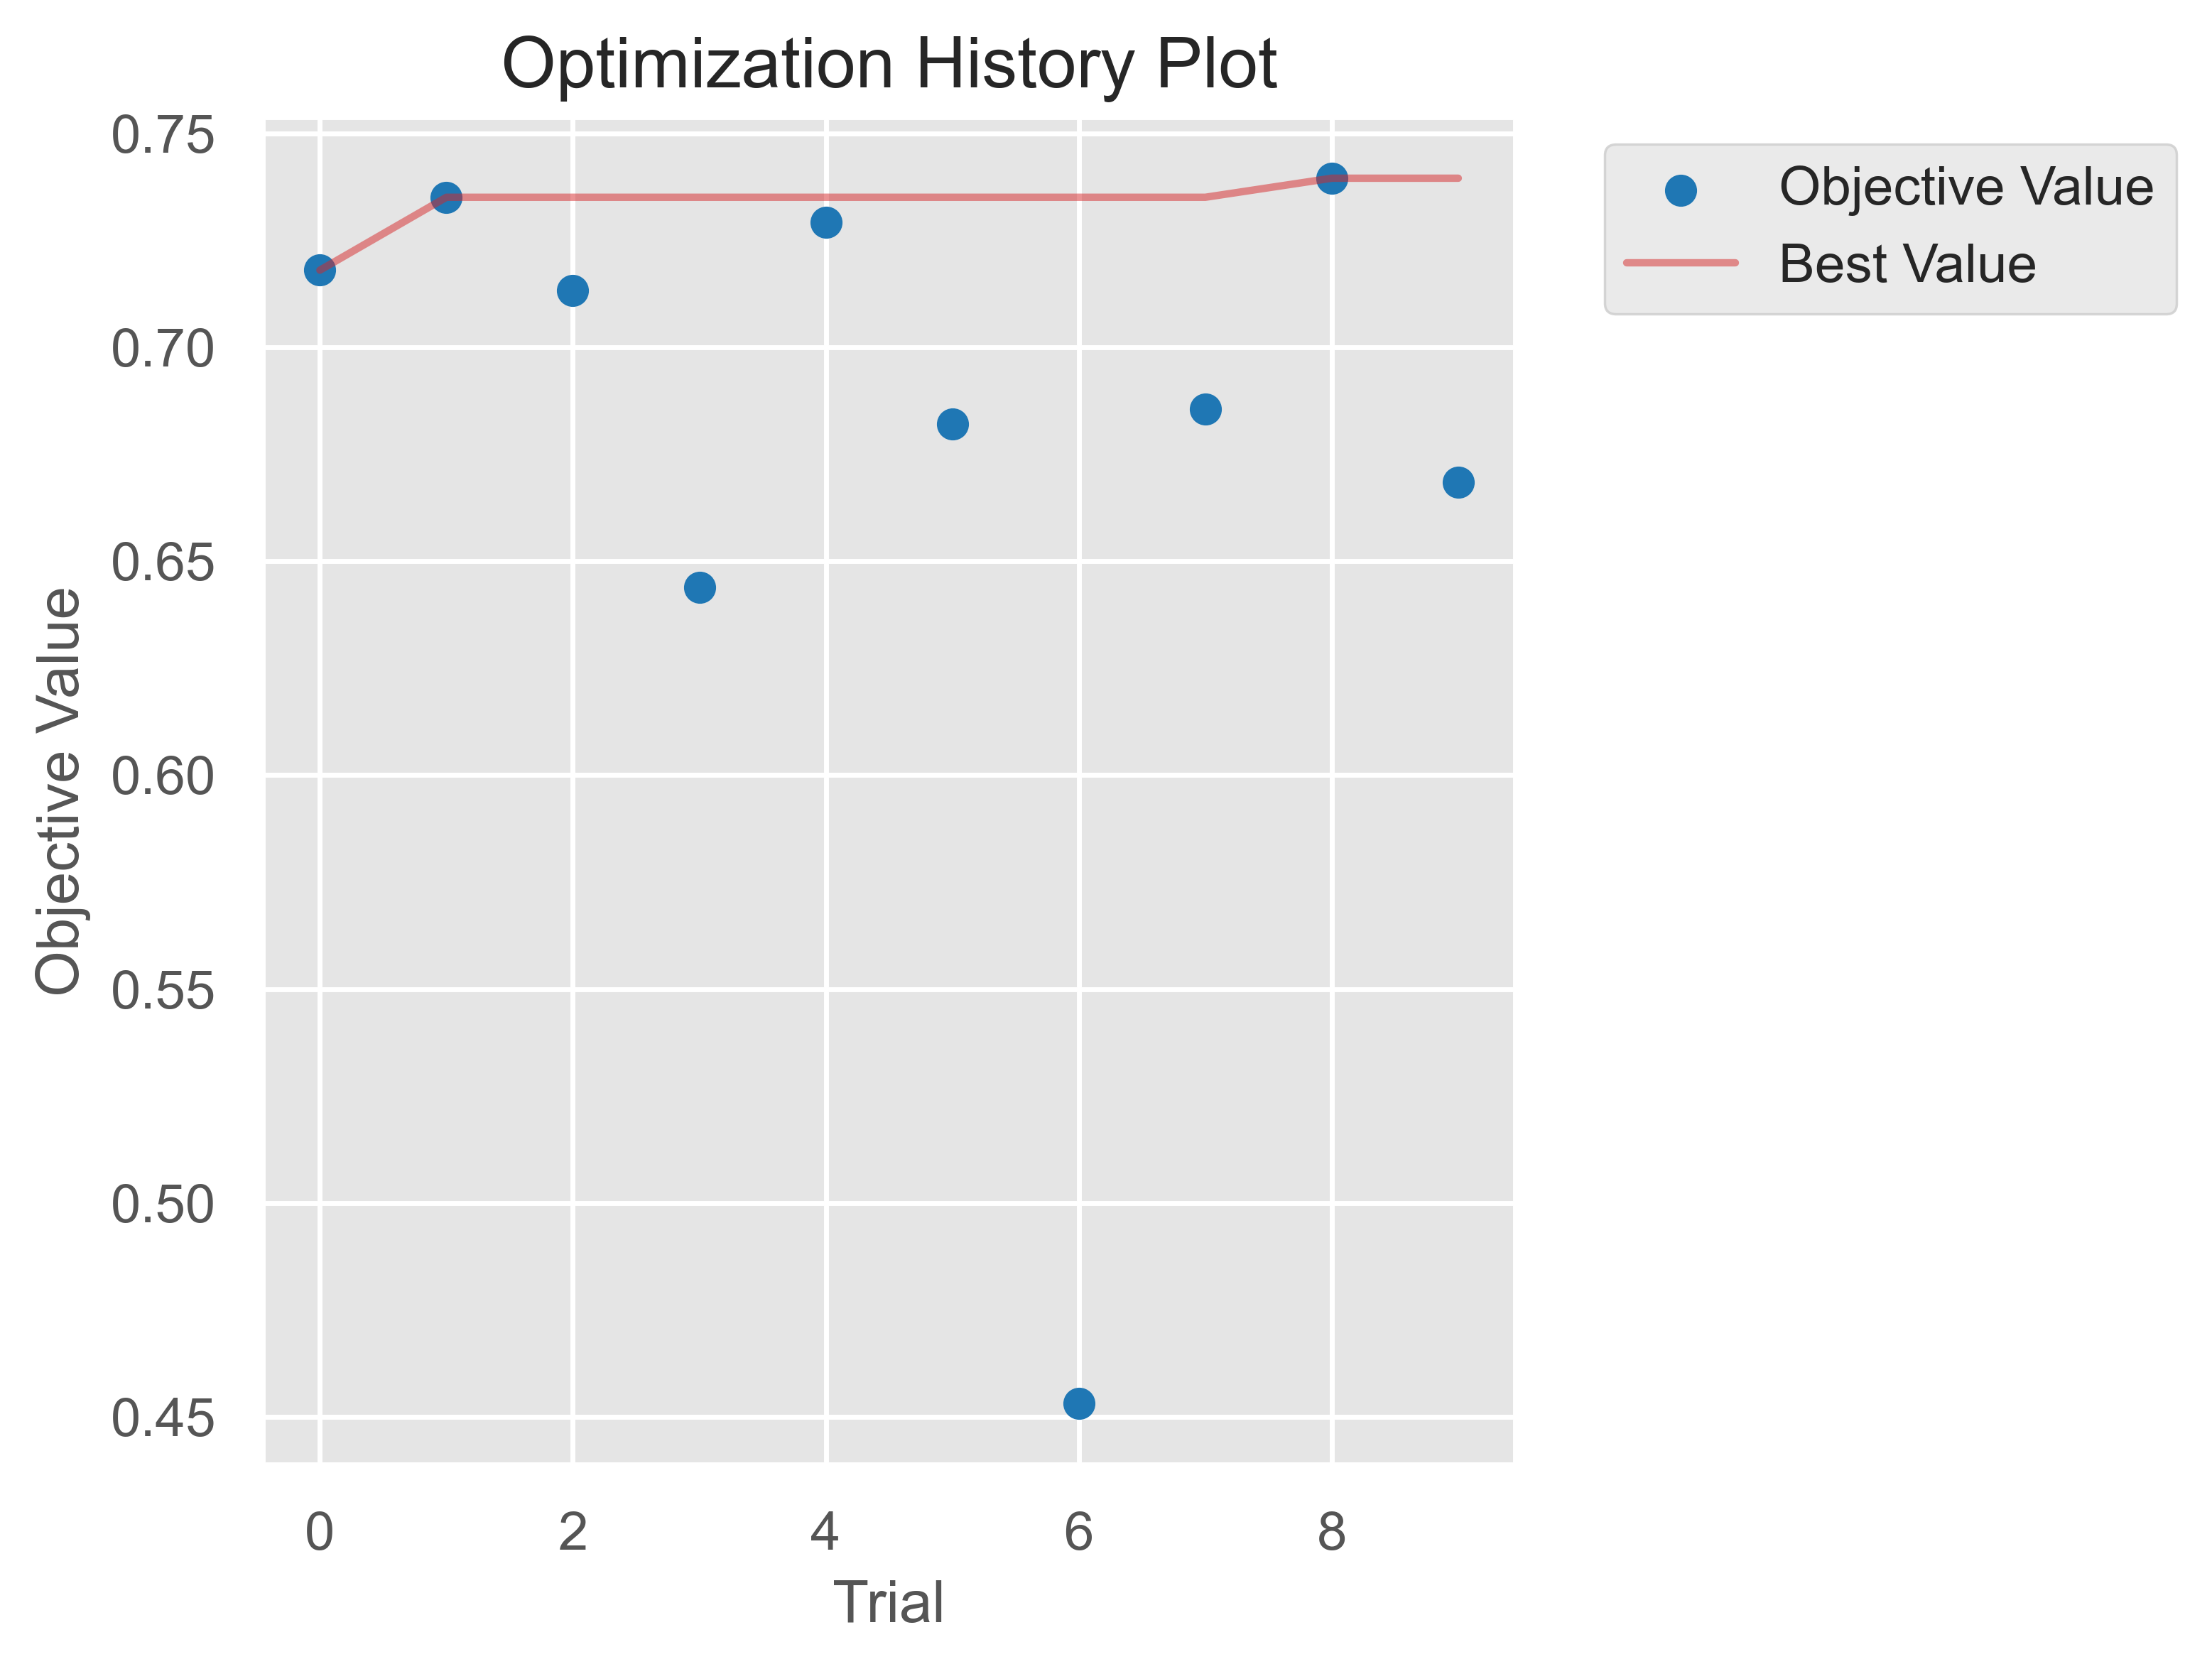

/var/folders/45/28s1lk4529l_kmclmk3p9g0h0000gp/T/ipykernel_22991/3054980109.py:8: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = opt_viz.plot_param_importances(study)


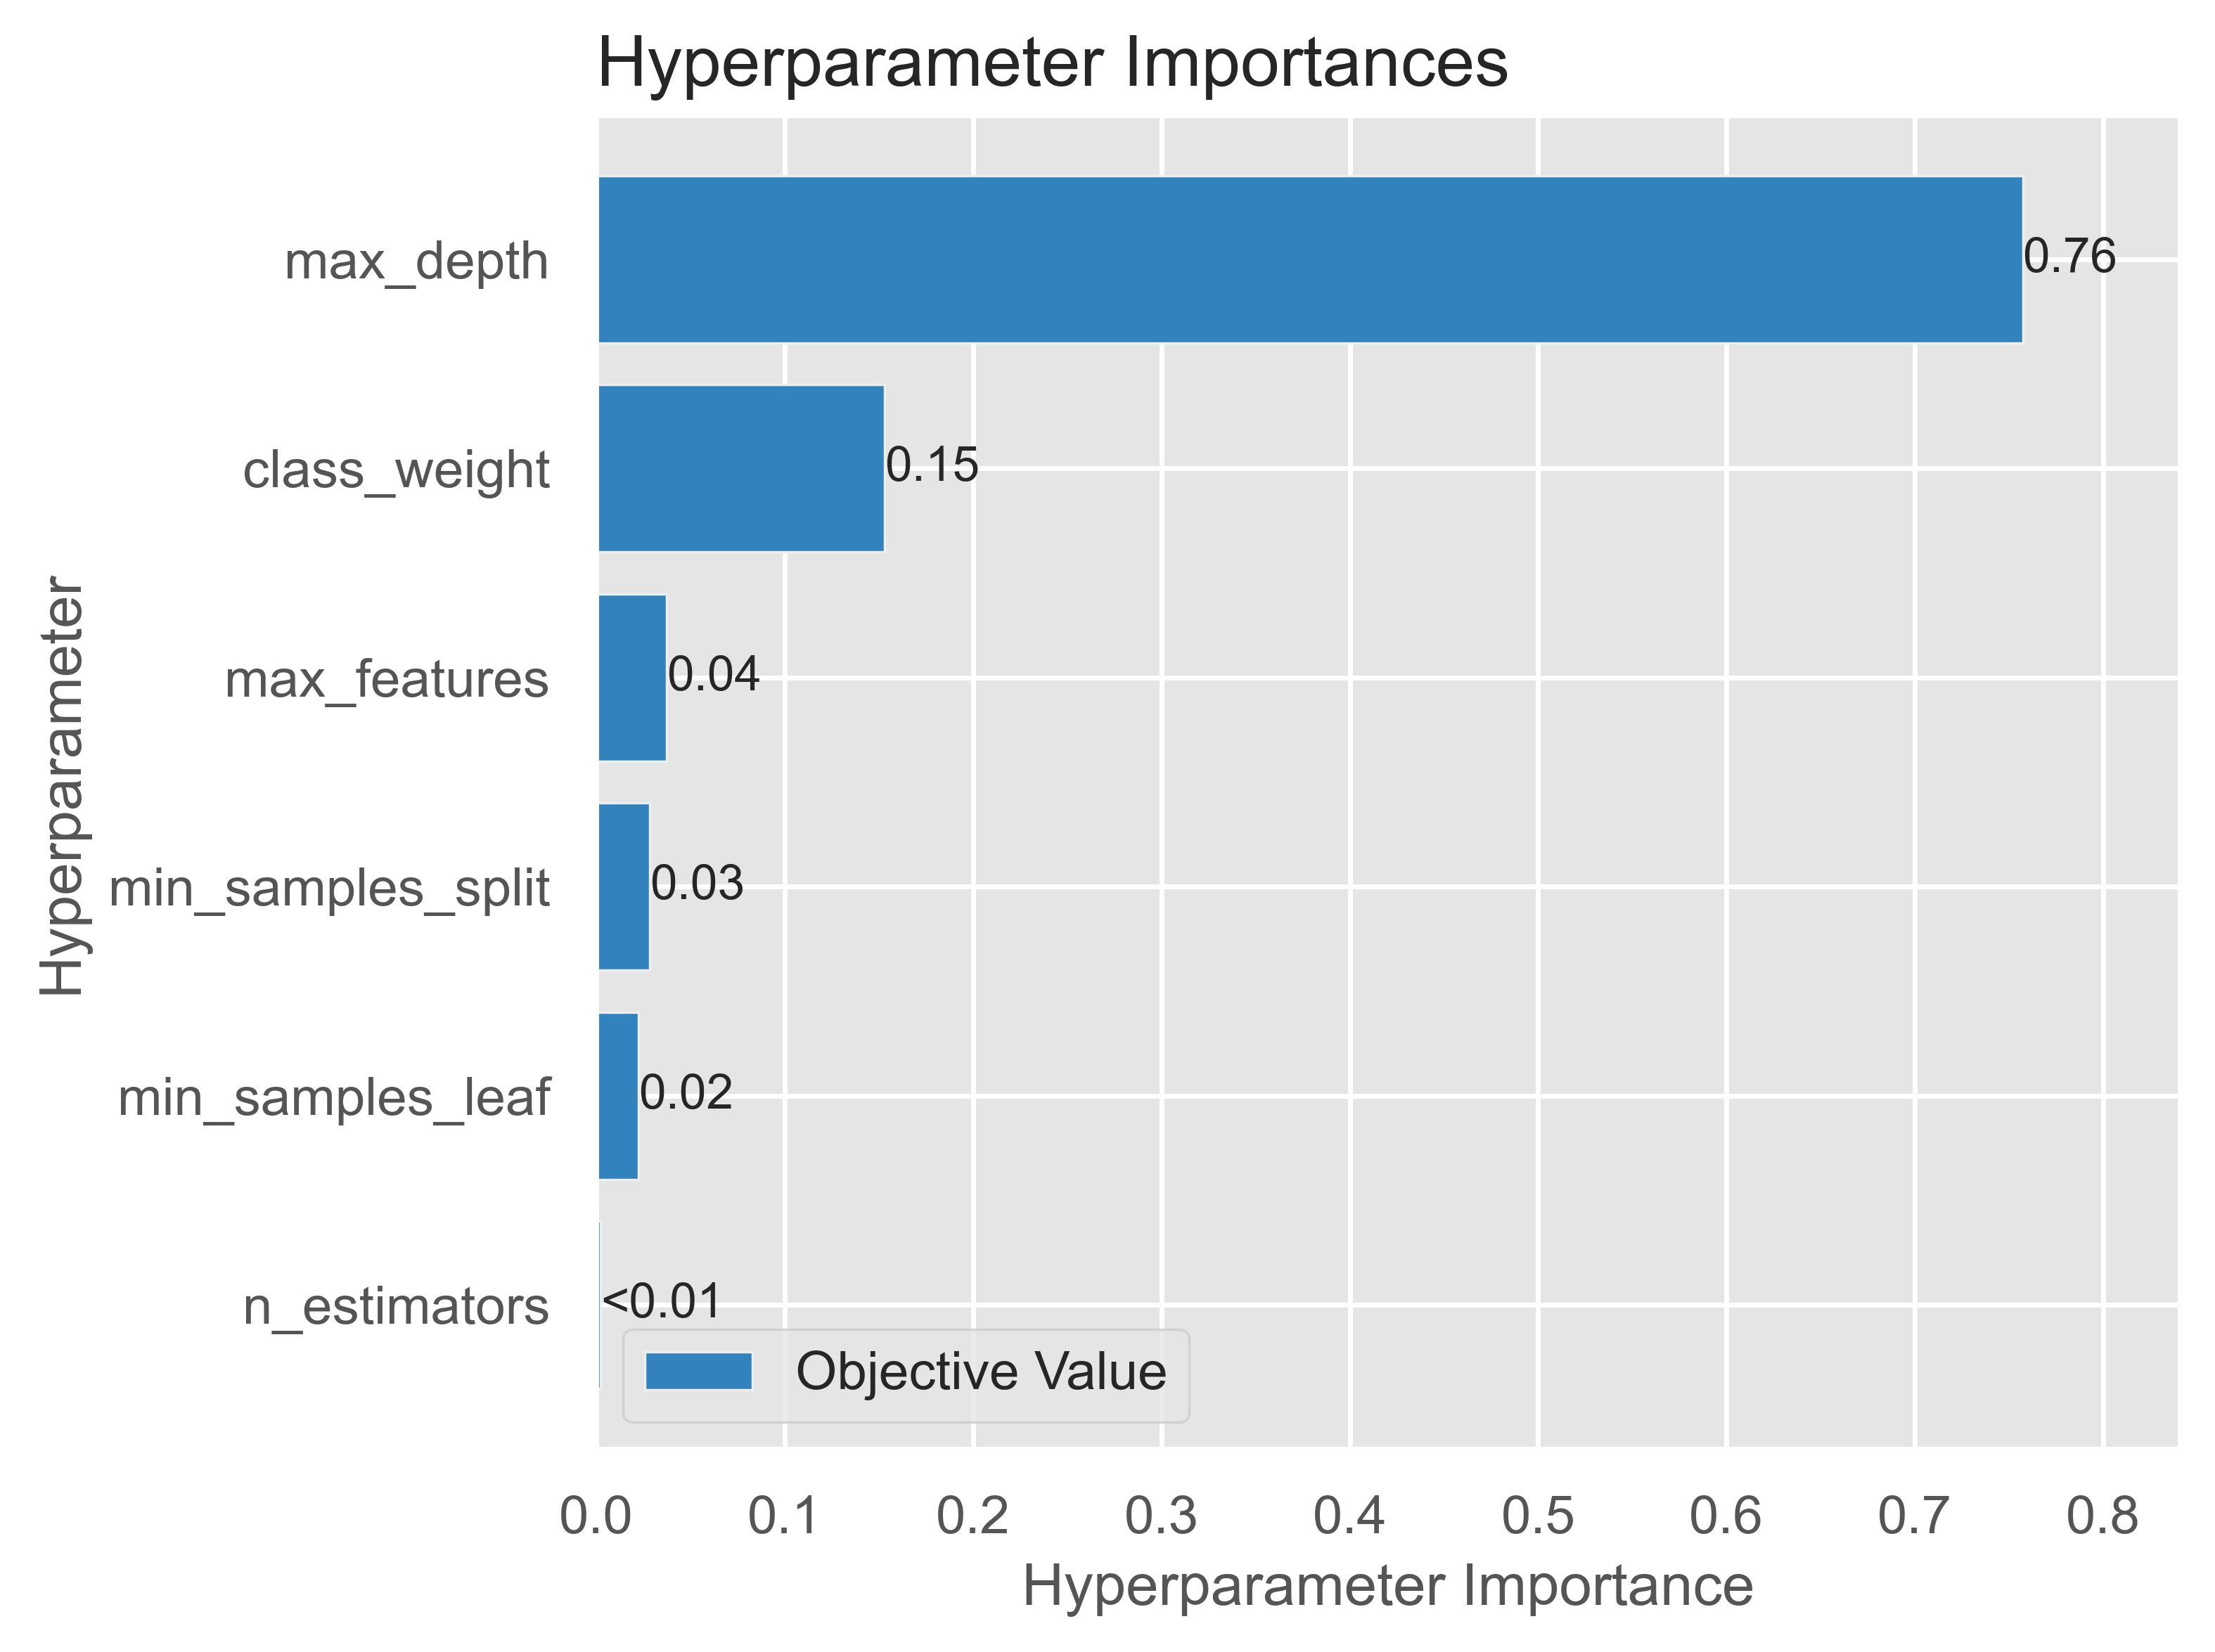

In [24]:
import optuna.visualization.matplotlib as opt_viz
import matplotlib.pyplot as plt

fig = opt_viz.plot_optimization_history(study)
plt.tight_layout()
plt.show()

fig = opt_viz.plot_param_importances(study)
plt.tight_layout()
plt.show()

In [25]:
lithology_keys = {
    30000: "Sandstone",
    65030: "Sandstone/Shale",
    65000: "Shale",
    80000: "Marl",
    74000: "Dolomite",
    70000: "Limestone",
    70032: "Chalk",
    88000: "Halite",
    86000: "Anhydrite",
    99000: "Tuff",
    90000: "Coal",
    93000: "Basement",
}

df["LITHO_NAME"] = df["FORCE_2020_LITHOFACIES_LITHOLOGY"].map(lithology_keys)

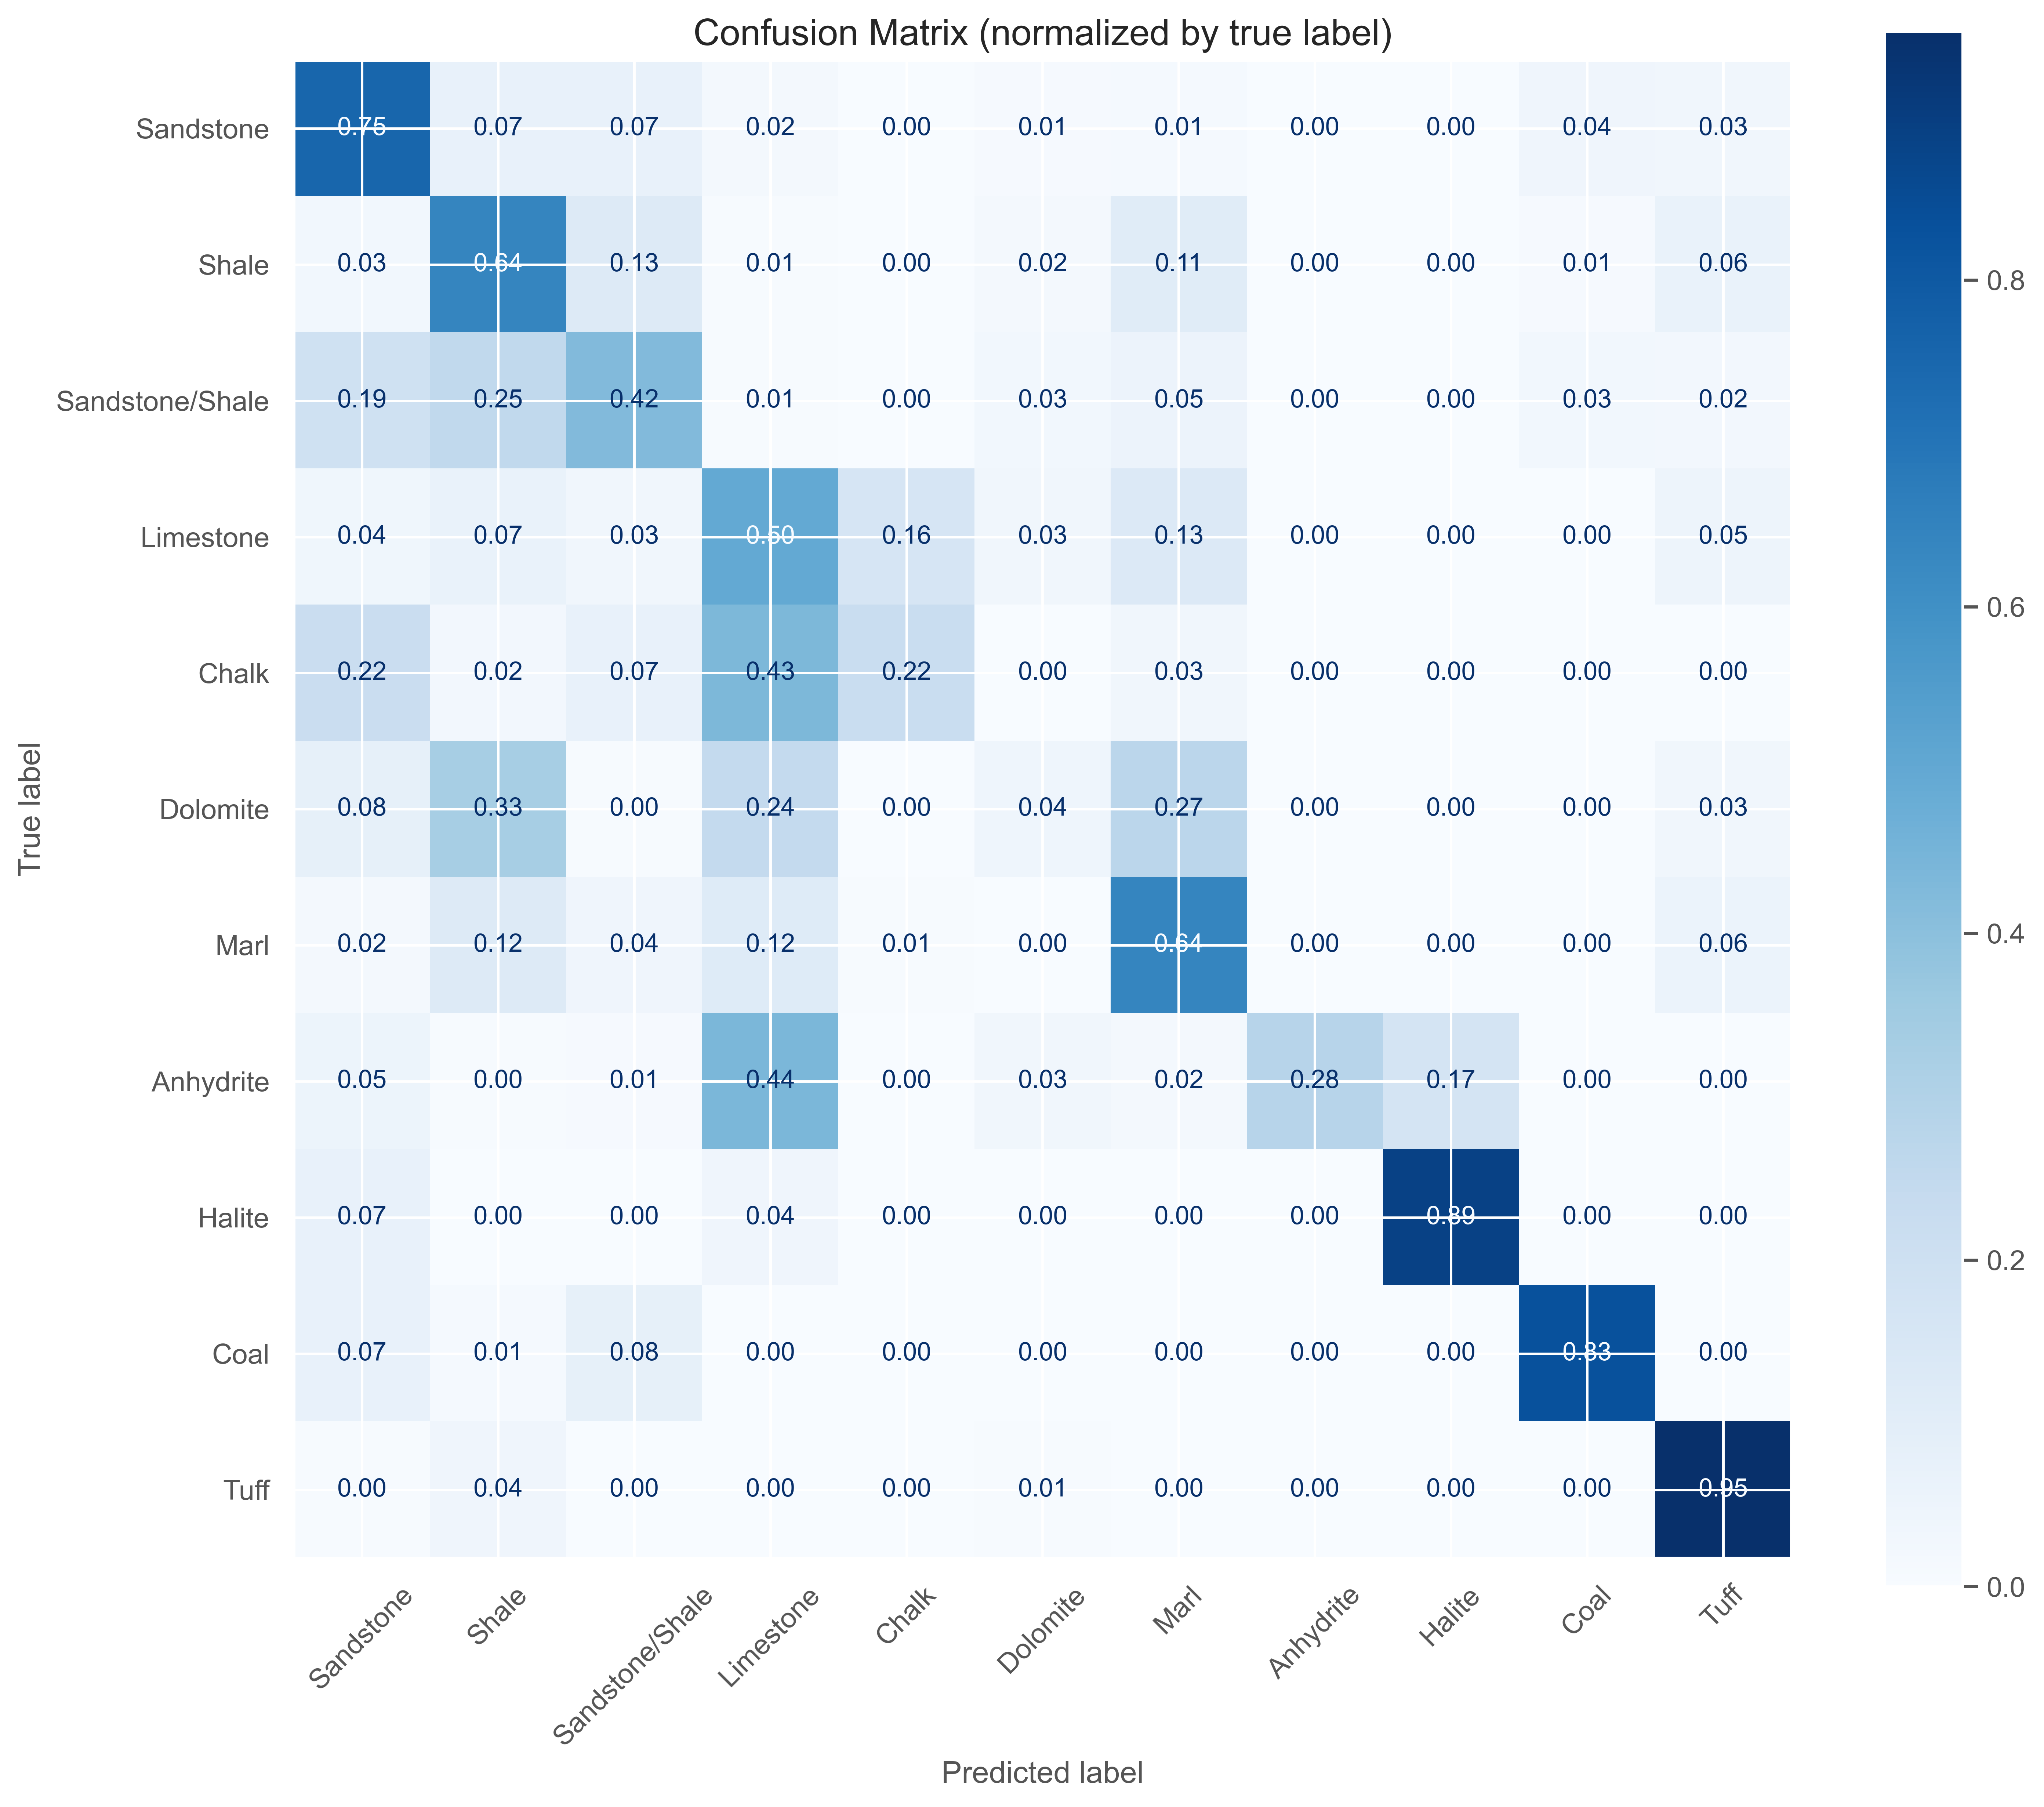

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

val_preds = pipeline_rf.predict(X_val)
labels_sorted = sorted(y_val.unique()) 
labels_names = [lithology_keys.get(l, str(l)) for l in labels_sorted]

cm = confusion_matrix(y_val, val_preds, labels=labels_sorted, normalize="true")

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format=".2f")
plt.title("Confusion Matrix (normalized by true label)")
plt.tight_layout()
plt.show()

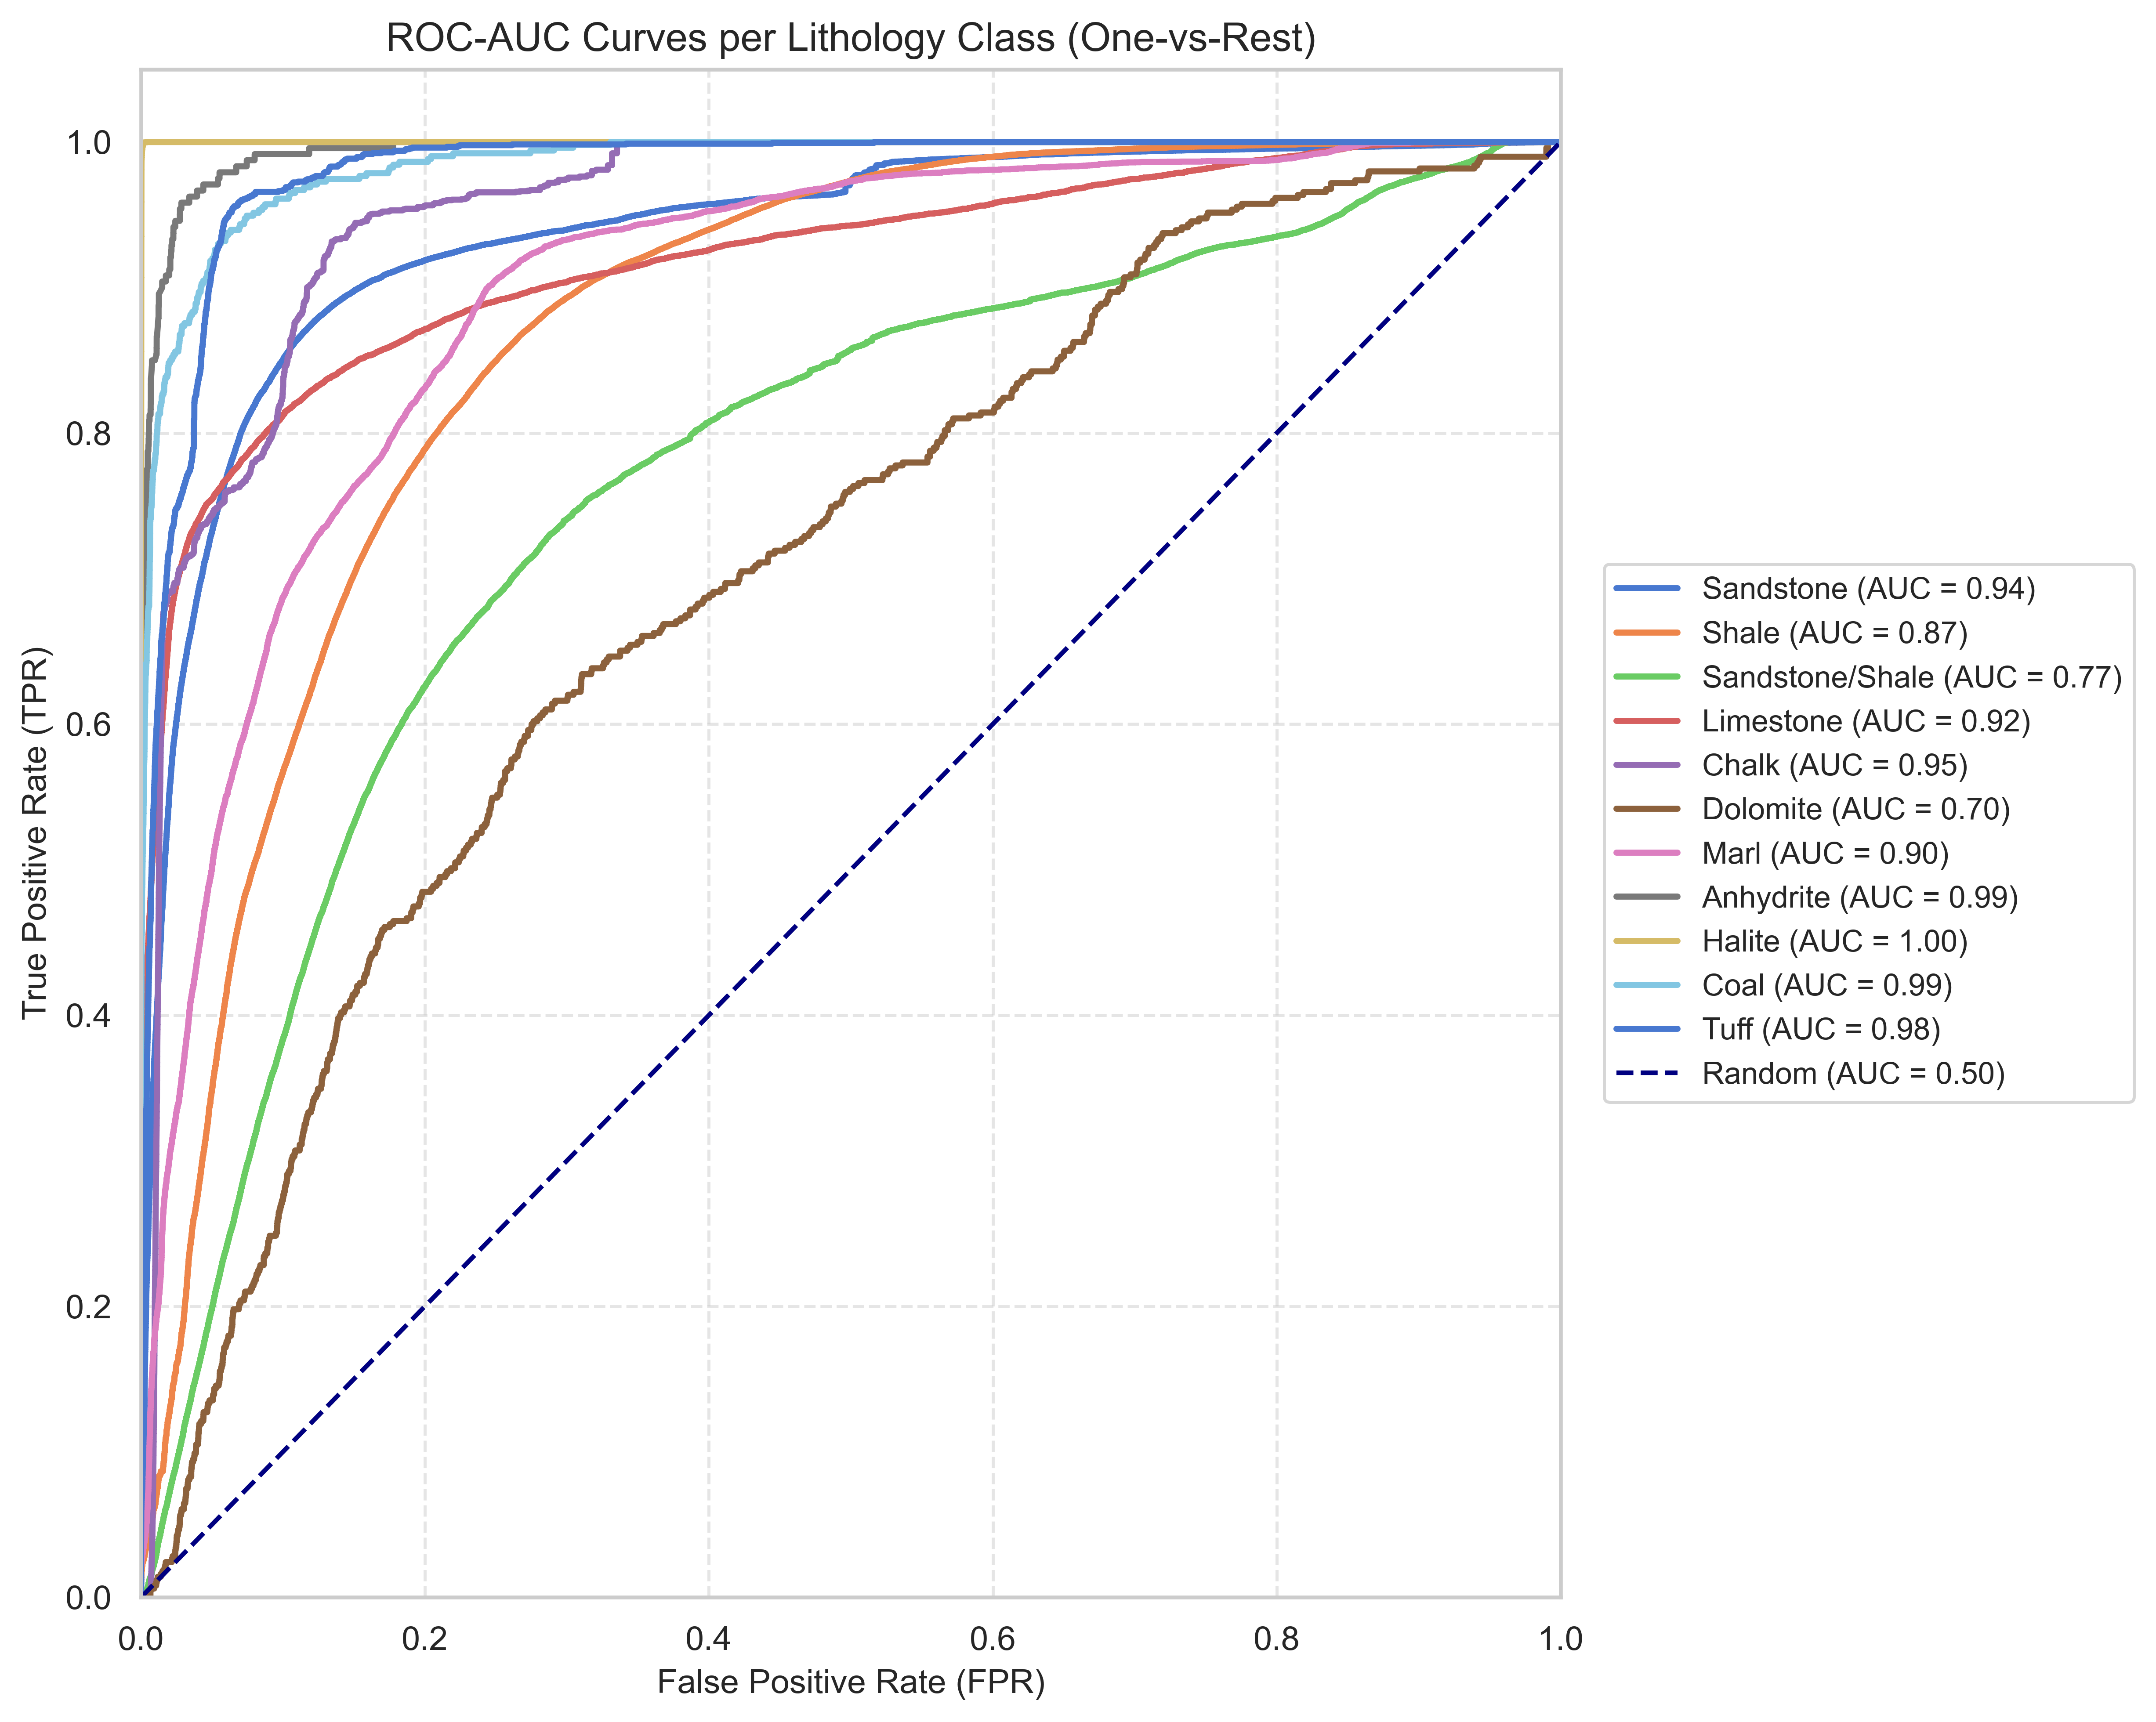

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
sns.set_palette(palette="muted")
plt.rcParams["figure.dpi"] = 500
plt.rcParams["savefig.dpi"] = 800
plt.rcParams["font.size"] = 12
plt.rcParams["lines.linewidth"] = 1.5


val_probs = pipeline_rf.predict_proba(X_val)
classes = pipeline_rf.classes_ 

plt.figure(figsize=(10, 8))

for i, class_code in enumerate(classes):
    y_true_binary = (y_val == class_code).astype(int)

    if y_true_binary.sum() == 0:
        continue
        
    y_score = val_probs[:, i]

    fpr, tpr, _ = roc_curve(y_true_binary, y_score)
    roc_auc = auc(fpr, tpr)
    
    class_name = lithology_keys.get(class_code, str(class_code))
    
    plt.plot(fpr, tpr, lw=2, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], color="navy", linestyle="--", lw=1.5, label="Random (AUC = 0.50)")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)", fontsize=11)
plt.ylabel("True Positive Rate (TPR)", fontsize=11)
plt.title("ROC-AUC Curves per Lithology Class (One-vs-Rest)", fontsize=13)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=10)  # Легенда вынесена вправо
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()